In [111]:
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [112]:
data = load_digits()
X, y = data.data, data.target
X = X.reshape((-1, 1, 8, 8))
X = torch.tensor(X, dtype=torch.float32) / 255.0
y = torch.tensor(y, dtype=torch.long)

In [113]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

In [114]:
train_loader = DataLoader(train_ds, batch_size=100, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=100, shuffle=False)

In [115]:
torch.manual_seed(101)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

In [126]:
class ConvolutionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3, 1)
        self.batchnorm1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 3, 1)
        self.batchnorm2 = nn.BatchNorm2d(16)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16 * 1 * 1, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.batchnorm1(x)
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.conv2(x))
        x = self.batchnorm2(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=1)
        return x

In [127]:
torch.manual_seed(42)
model = ConvolutionNetwork()

In [128]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [129]:
epochs = 60
training_losses = []
test_losses = []
train_correct_list = []
test_correct_list = []

for i in range(epochs):
    model.train()
    train_correct = 0
    train_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        predicted = torch.max(y_pred, 1)[1]
        train_correct += (predicted == y_batch).sum().item()
        train_loss += loss.item()

    training_losses.append(train_loss / len(train_loader))
    train_correct_list.append(train_correct)

    model.eval()
    test_correct = 0
    test_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_val = model(X_batch)
            loss = criterion(y_val, y_batch)
            test_loss += loss.item()
            
            predicted = torch.max(y_val, 1)[1]
            test_correct += (predicted == y_batch).sum().item()

    test_losses.append(test_loss / len(test_loader))
    test_correct_list.append(test_correct)

    print(f'Epoch {i + 1}/{epochs}, Train Loss: {training_losses[-1]:.4f}, Train Accuracy: {train_correct / len(train_ds):.4f}, Test Loss: {test_losses[-1]:.4f}, Test Accuracy: {test_correct / len(test_ds):.4f}')

Epoch 1/60, Train Loss: 2.2717, Train Accuracy: 0.3751, Test Loss: 2.3020, Test Accuracy: 0.1361
Epoch 2/60, Train Loss: 2.1089, Train Accuracy: 0.5136, Test Loss: 2.2770, Test Accuracy: 0.1056
Epoch 3/60, Train Loss: 1.8857, Train Accuracy: 0.6458, Test Loss: 2.1065, Test Accuracy: 0.3806
Epoch 4/60, Train Loss: 1.7296, Train Accuracy: 0.7697, Test Loss: 1.7266, Test Accuracy: 0.8222
Epoch 5/60, Train Loss: 1.6571, Train Accuracy: 0.8344, Test Loss: 1.6411, Test Accuracy: 0.8556
Epoch 6/60, Train Loss: 1.6323, Train Accuracy: 0.8462, Test Loss: 1.6117, Test Accuracy: 0.8694
Epoch 7/60, Train Loss: 1.6072, Train Accuracy: 0.8664, Test Loss: 1.6119, Test Accuracy: 0.8667
Epoch 8/60, Train Loss: 1.5875, Train Accuracy: 0.8887, Test Loss: 1.5952, Test Accuracy: 0.9000
Epoch 9/60, Train Loss: 1.5605, Train Accuracy: 0.9269, Test Loss: 1.5527, Test Accuracy: 0.9417
Epoch 10/60, Train Loss: 1.5329, Train Accuracy: 0.9492, Test Loss: 1.5383, Test Accuracy: 0.9333
Epoch 11/60, Train Loss: 1.51

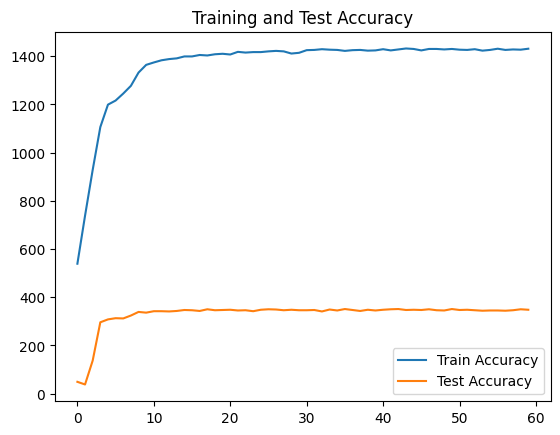

In [130]:
plt.plot(train_correct_list, label="Train Accuracy")
plt.plot(test_correct_list, label="Test Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.show()

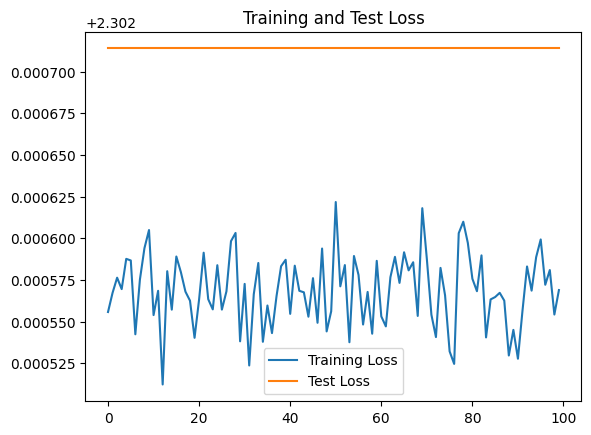

In [110]:
plt.plot(training_losses, label="Training Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.show()


In [132]:
torch.save(model.state_dict, "simple_cnn.pt")